# Model Validation Framework

**Goal:** Establish the validation infrastructure missing from the existing EDA notebooks
and produce a concrete pass/fail scorecard answering "are we ready to train an xG model?"

**Design doc:** `docs/xg_model_components/06_model_validation_framework.md`

**Steps:**
1. Base rate stability analysis
2. Statistical rigor retrofit (bootstrap CIs, chi-squared, effect sizes)
3. Temporal cross-validation harness
4. Calibration analysis
5. Conditional feature importance (ablation)
5b. Venue bias per-season validation
6. Leakage audit table
7. Validation scorecard

**Data source:** `shot_events`, `games`, `game_context`, `venue_bias_diagnostics` tables in `data/nhl_data.db`

In [1]:
import os
import sys
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy import stats as sp_stats
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    log_loss,
    roc_auc_score,
    average_precision_score,
)
from sklearn.preprocessing import OneHotEncoder

# Add src/ to path - handle CWD being project root or notebooks/
for _candidate in [os.path.join(os.getcwd(), "src"),
                   os.path.join(os.getcwd(), "..", "src")]:
    _candidate = os.path.abspath(_candidate)
    if os.path.isdir(_candidate) and _candidate not in sys.path:
        sys.path.insert(0, _candidate)
        break

from database import (
    DATABASE_PATH,
    _MIN_TRAINING_SEASON,
    _XG_EVENT_SCHEMA_VERSION,
    VALID_MANPOWER_STATES,
    VALID_SCORE_STATES,
    VALID_SHOT_TYPES,
    load_training_shot_events,
    validate_shot_events_quality,
)

from validation import (
    CALIBRATION_N_BINS,
    CALIBRATION_SLOPE_TARGET_HIGH,
    CALIBRATION_SLOPE_TARGET_LOW,
    COHEN_H_SMALL,
    HOSMER_LEMESHOW_ALPHA,
    MIN_SHOTS_PER_CELL,
    MIN_TRAIN_SEASONS,
    N_BOOTSTRAP_SAMPLES,
    bootstrap_goal_rate_ci,
    calibration_slope_intercept,
    cohens_h,
    hosmer_lemeshow_test,
    run_temporal_cv,
)

sns.set_theme(style="whitegrid")
print(f"Database: {DATABASE_PATH}")
conn = sqlite3.connect(DATABASE_PATH)
conn.row_factory = sqlite3.Row
cur = conn.cursor()
print("Connected.")


Database: C:\Users\micha\source\repos\pythonNHLPxPScraperAndDefenderAnalysis\data\nhl_data.db
Connected.


In [2]:
TRAINING_SHOT_COLUMNS = (
    "game_id",
    "event_idx",
    "season",
    "venue_name",
    "period",
    "shot_type",
    "distance_to_goal",
    "angle_to_goal",
    "manpower_state",
    "score_state",
    "seconds_since_faceoff",
    "faceoff_zone_code",
    "is_goal",
)

training_rows = load_training_shot_events(conn)

cur.execute("DROP TABLE IF EXISTS training_shots")
cur.execute("""
    CREATE TEMP TABLE training_shots (
        game_id INTEGER,
        event_idx INTEGER,
        season TEXT,
        venue_name TEXT,
        period INTEGER,
        shot_type TEXT,
        distance_to_goal REAL,
        angle_to_goal REAL,
        manpower_state TEXT,
        score_state TEXT,
        seconds_since_faceoff REAL,
        faceoff_zone_code TEXT,
        is_goal INTEGER
    )
""")

if training_rows:
    cur.executemany(
        """
        INSERT INTO training_shots (
            game_id, event_idx, season, venue_name, period, shot_type,
            distance_to_goal, angle_to_goal, manpower_state, score_state,
            seconds_since_faceoff, faceoff_zone_code, is_goal
        ) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)
        """,
        [[row[column] for column in TRAINING_SHOT_COLUMNS] for row in training_rows],
    )

cur.execute("SELECT COUNT(*) FROM shot_events")
raw_total_shots = cur.fetchone()[0]
cur.execute("SELECT COUNT(*) FROM games")
total_games = cur.fetchone()[0]

total_shots = len(training_rows)
total_goals = sum(int(row["is_goal"] or 0) for row in training_rows)
overall_base_rate = total_goals / total_shots if total_shots else 0

print(f"Raw shot rows:                  {raw_total_shots:,}")
print(f"Training-eligible shot rows:    {total_shots:,}")
print(f"Total games:                    {total_games:,}")
print(f"Training-eligible goals:        {total_goals:,}")
print(f"Training base rate:             {overall_base_rate:.4f} ({overall_base_rate*100:.2f}%)")
print(f"Training contract: schema={_XG_EVENT_SCHEMA_VERSION}, min season={_MIN_TRAINING_SEASON}, non-null geometry/type, non-blocked shots")

quality = validate_shot_events_quality(conn)
print("\nData quality check:")
all_clean = True
for check, count in quality.items():
    status = "PASS" if count == 0 else f"FAIL ({count:,} rows)"
    if count > 0:
        all_clean = False
    print(f"  {check}: {status}")
if all_clean:
    print("  All data-contract checks passed.")
if total_shots == 0:
    print("\n*** No training-eligible shots found. Run current-schema backfill first. ***")


Raw shot rows:                  2,122,963
Training-eligible shot rows:    1,965,107
Total games:                    26,372
Training-eligible goals:        138,406
Training base rate:             0.0704 (7.04%)
Training contract: schema=v5, min season=20092010, non-null geometry/type, non-blocked shots



Data quality check:
  invalid_shot_event_type_rows: PASS
  invalid_shot_type_rows: PASS
  invalid_manpower_state_rows: PASS
  invalid_score_state_rows: PASS
  x_coord_out_of_range_rows: PASS
  y_coord_out_of_range_rows: PASS
  invalid_is_goal_rows: PASS
  negative_time_remaining_rows: PASS
  duplicate_game_event_rows: PASS
  All data-contract checks passed.


---
## Step 1: Base Rate Stability Analysis

Before training any model, we need to know whether the thing we are predicting (goal probability)
is stable across the segments we plan to model. If the base rate shifts by >1 percentage point
across seasons or manpower states, the model needs segment-specific intercepts or recalibration.

**Dimensions checked:**
- Season (temporal drift)
- Manpower state (structural: PP goals are far more likely)
- Period (game-state: empty-net effects in period 3)
- Era (pre-tracking vs. post-tracking, pre-2019 vs. 2019+)

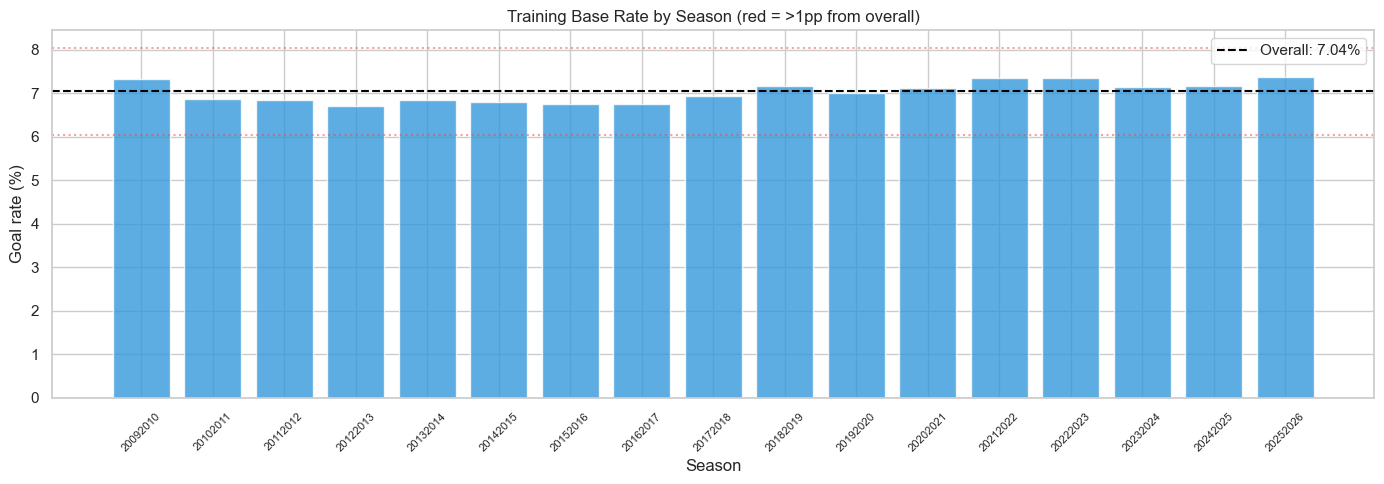


Season            Shots    Goals     Rate Delta (pp)
----------------------------------------------------
20092010        111,771    8,184    7.32%     +0.28
20102011        117,916    8,110    6.88%     -0.16
20112012        115,030    7,870    6.84%     -0.20
20122013         66,747    4,477    6.71%     -0.33
20132014        117,039    8,021    6.85%     -0.19
20142015        116,210    7,904    6.80%     -0.24
20152016        115,744    7,829    6.76%     -0.28
20162017        118,625    8,009    6.75%     -0.29
20172018        126,072    8,745    6.94%     -0.10
20182019        124,147    8,901    7.17%     +0.13
20192020        113,721    7,963    7.00%     -0.04
20202021         79,115    5,632    7.12%     +0.08
20212022        129,792    9,554    7.36%     +0.32
20222023        130,173    9,560    7.34%     +0.30
20232024        131,248    9,366    7.14%     +0.10
20242025        128,577    9,206    7.16%     +0.12
20252026        123,180    9,075    7.37%     +0.33

All seas

In [3]:
cur.execute("""
    SELECT season,
           COUNT(*)                AS shots,
           SUM(is_goal)            AS goals,
           ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    WHERE season IS NOT NULL
    GROUP BY season
    ORDER BY season
""")
season_rows = cur.fetchall()

seasons = [str(r[0]) for r in season_rows]
season_shots = [r[1] for r in season_rows]
season_goals = [r[2] for r in season_rows]
season_rates = [r[3] for r in season_rows]

BASE_RATE_DRIFT_THRESHOLD_PP = 1.0
flagged_seasons = [
    (s, r) for s, r in zip(seasons, season_rates)
    if abs(r - overall_base_rate) * 100 > BASE_RATE_DRIFT_THRESHOLD_PP
]

fig, ax = plt.subplots(figsize=(14, 5))
colors = [
    "#e74c3c" if abs(r - overall_base_rate) * 100 > BASE_RATE_DRIFT_THRESHOLD_PP
    else "#3498db"
    for r in season_rates
]
ax.bar(seasons, [r * 100 for r in season_rates], color=colors, alpha=0.8)
ax.axhline(y=overall_base_rate * 100, color="black", linestyle="--",
           label=f"Overall: {overall_base_rate*100:.2f}%")
ax.axhline(y=(overall_base_rate + BASE_RATE_DRIFT_THRESHOLD_PP / 100) * 100,
           color="#e74c3c", linestyle=":", alpha=0.5)
ax.axhline(y=(overall_base_rate - BASE_RATE_DRIFT_THRESHOLD_PP / 100) * 100,
           color="#e74c3c", linestyle=":", alpha=0.5)
ax.set_xlabel("Season")
ax.set_ylabel("Goal rate (%)")
ax.set_title("Training Base Rate by Season (red = >1pp from overall)")
ax.legend()
plt.xticks(rotation=45, fontsize=8)
fig.tight_layout()
plt.show()

print(f"\n{'Season':<12} {'Shots':>10} {'Goals':>8} {'Rate':>8} {'Delta (pp)':>10}")
print("-" * 52)
for s, sh, g, r in zip(seasons, season_shots, season_goals, season_rates):
    delta = (r - overall_base_rate) * 100
    flag = " ***" if abs(delta) > BASE_RATE_DRIFT_THRESHOLD_PP else ""
    print(f"{s:<12} {sh:>10,} {g:>8,} {r*100:>7.2f}% {delta:>+9.2f}{flag}")

if flagged_seasons:
    print(f"\nWARNING: {len(flagged_seasons)} season(s) exceed {BASE_RATE_DRIFT_THRESHOLD_PP}pp drift threshold.")
    print("Model may need era-specific intercepts or recalibration.")
else:
    print(f"\nAll seasons within {BASE_RATE_DRIFT_THRESHOLD_PP}pp of overall base rate.")


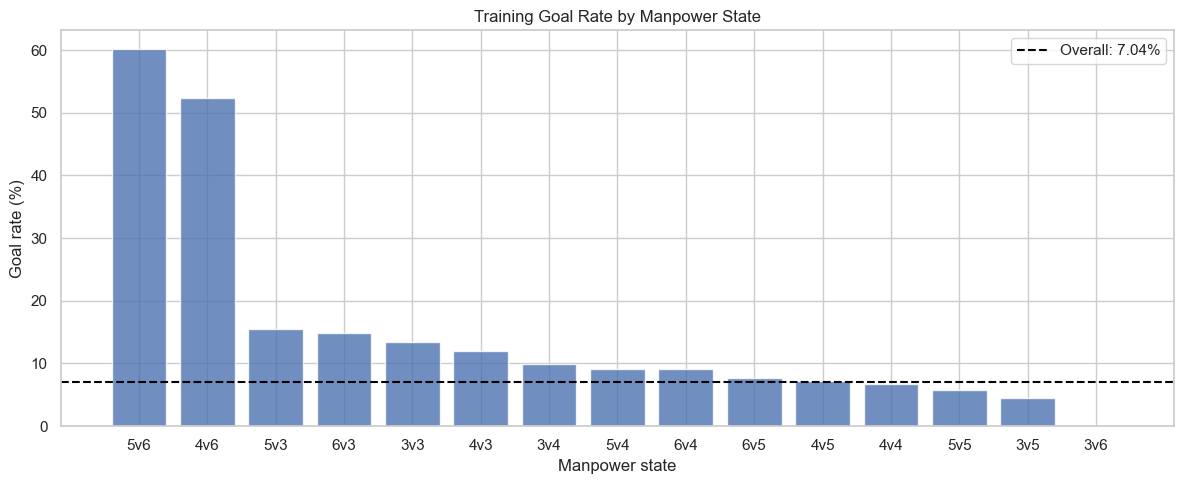


State           Shots    Goals     Rate vs Overall
--------------------------------------------------
5v6             9,471    5,695   60.13%    +53.09pp
4v6               688      360   52.33%    +45.29pp
5v3            10,114    1,564   15.46%     +8.42pp
6v3               135       20   14.81%     +7.77pp
3v3            15,336    2,057   13.41%     +6.37pp
4v3             5,641      679   12.04%     +5.00pp
3v4               312       31    9.94%     +2.90pp
5v4           271,870   24,907    9.16%     +2.12pp
6v4             4,577      417    9.11%     +2.07pp
6v5            31,435    2,410    7.67%     +0.63pp
4v5            46,562    3,371    7.24%     +0.20pp
4v4            34,698    2,361    6.80%     -0.24pp
5v5         1,497,614   87,083    5.81%     -1.23pp
3v5               351       16    4.56%     -2.48pp
3v6                 4        0    0.00%     -7.04pp

Even strength: 1,547,648 shots, 91,501 goals, rate = 5.91%

Power play: 323,772 shots, 29,997 goals, rate = 9.26%

S

In [4]:
cur.execute("""
    SELECT manpower_state,
           COUNT(*)          AS shots,
           SUM(is_goal)      AS goals,
           ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    WHERE manpower_state IS NOT NULL
    GROUP BY manpower_state
    ORDER BY goal_rate DESC
""")
mp_rows = cur.fetchall()

mp_states = [r[0] for r in mp_rows]
mp_shots = [r[1] for r in mp_rows]
mp_goals = [r[2] for r in mp_rows]
mp_rates = [r[3] for r in mp_rows]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(mp_states, [r * 100 for r in mp_rates], alpha=0.8)
ax.axhline(y=overall_base_rate * 100, color="black", linestyle="--",
           label=f"Overall: {overall_base_rate*100:.2f}%")
ax.set_xlabel("Manpower state")
ax.set_ylabel("Goal rate (%)")
ax.set_title("Training Goal Rate by Manpower State")
ax.legend()
fig.tight_layout()
plt.show()

print(f"\n{'State':<10} {'Shots':>10} {'Goals':>8} {'Rate':>8} {'vs Overall':>10}")
print("-" * 50)
for st, sh, g, r in zip(mp_states, mp_shots, mp_goals, mp_rates):
    delta = (r - overall_base_rate) * 100
    print(f"{st:<10} {sh:>10,} {g:>8,} {r*100:>7.2f}% {delta:>+9.2f}pp")

EVEN_STRENGTH_STATES = {"5v5", "4v4", "3v3"}
PP_STATES = {"5v4", "5v3", "4v3", "6v5", "6v4", "6v3"}
SH_STATES = {"4v5", "3v5", "3v4", "5v6", "4v6", "3v6"}

for label, group in [("Even strength", EVEN_STRENGTH_STATES),
                     ("Power play", PP_STATES),
                     ("Short-handed", SH_STATES)]:
    group_shots = sum(sh for st, sh in zip(mp_states, mp_shots) if st in group)
    group_goals = sum(g for st, g in zip(mp_states, mp_goals) if st in group)
    group_rate = group_goals / group_shots if group_shots else 0
    print(f"\n{label}: {group_shots:,} shots, {group_goals:,} goals, "
          f"rate = {group_rate*100:.2f}%")


In [5]:
cur.execute("""
    SELECT period,
           COUNT(*)          AS shots,
           SUM(is_goal)      AS goals,
           ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    GROUP BY period
    ORDER BY period
""")
period_rows = cur.fetchall()

print(f"{'Period':<10} {'Shots':>10} {'Goals':>8} {'Rate':>8}")
print("-" * 40)
for r in period_rows:
    print(f"{r[0]:<10} {r[1]:>10,} {r[2]:>8,} {r[3]*100:>7.2f}%")

print("\nNote: Period 3 rate may be inflated by empty-net goals.")
print("OT periods (4+) have small samples and different rules (3v3 since 2015-16).")


Period          Shots    Goals     Rate
----------------------------------------
1             627,653   38,636    6.16%
2             666,632   45,897    6.88%
3             622,085   45,950    7.39%
4              32,951    3,173    9.63%
5              15,547    4,740   30.49%
6                 161        8    4.97%
7                  66        1    1.52%
8                  12        1    8.33%

Note: Period 3 rate may be inflated by empty-net goals.
OT periods (4+) have small samples and different rules (3v3 since 2015-16).


In [6]:
TRACKING_ERA_FIRST_SEASON = "20192020"
COVID_SEASON = "20202021"

cur.execute("""
    SELECT
        CASE
            WHEN season = ? THEN 'COVID (2020-21)'
            WHEN season >= ? THEN 'Post-tracking (2019+)'
            ELSE 'Pre-tracking (<2019)'
        END AS era,
        COUNT(*)          AS shots,
        SUM(is_goal)      AS goals,
        ROUND(CAST(SUM(is_goal) AS REAL) / COUNT(*), 4) AS goal_rate
    FROM training_shots
    WHERE season IS NOT NULL
    GROUP BY era
    ORDER BY era
""", (COVID_SEASON, TRACKING_ERA_FIRST_SEASON))
era_rows = cur.fetchall()

print(f"{'Era':<30} {'Shots':>10} {'Goals':>8} {'Rate':>8} {'vs Overall':>10}")
print("-" * 70)
for r in era_rows:
    delta = (r[3] - overall_base_rate) * 100
    print(f"{r[0]:<30} {r[1]:>10,} {r[2]:>8,} {r[3]*100:>7.2f}% {delta:>+9.2f}pp")

print("\nIf era differences exceed 1pp, consider era-aware train/test splits")
print("or separate model intercepts per era.")


Era                                 Shots    Goals     Rate vs Overall
----------------------------------------------------------------------
COVID (2020-21)                    79,115    5,632    7.12%     +0.08pp
Post-tracking (2019+)             756,691   54,724    7.23%     +0.19pp
Pre-tracking (<2019)            1,129,301   78,050    6.91%     -0.13pp

If era differences exceed 1pp, consider era-aware train/test splits
or separate model intercepts per era.


In [7]:
# ── 1e. Step 1 summary ───────────────────────────────────────────────

print("=" * 60)
print("STEP 1 SUMMARY: Base Rate Stability")
print("=" * 60)
print(f"\nOverall base rate: {overall_base_rate*100:.2f}%")
print(f"Season range: {seasons[0]} to {seasons[-1]}" if seasons else "No season data")

# Compute spread
if season_rates:
    rate_min = min(season_rates)
    rate_max = max(season_rates)
    rate_spread_pp = (rate_max - rate_min) * 100
    print(f"Season rate range: {rate_min*100:.2f}% to {rate_max*100:.2f}% "
          f"(spread = {rate_spread_pp:.2f}pp)")

print(f"\nSeasons exceeding {BASE_RATE_DRIFT_THRESHOLD_PP}pp drift: "
      f"{len(flagged_seasons)}")

# Decision
if len(flagged_seasons) == 0:
    print("\nDECISION: Base rate is stable. A single intercept is likely sufficient.")
elif len(flagged_seasons) <= 2:
    print("\nDECISION: Minor drift detected. Monitor during temporal CV.")
    print("If calibration degrades on drifted seasons, add era as a feature.")
else:
    print("\nDECISION: Significant drift. Model MUST account for temporal shifts.")
    print("Options: era feature, season-specific intercepts, or recalibration layer.")

STEP 1 SUMMARY: Base Rate Stability

Overall base rate: 7.04%
Season range: 20092010 to 20252026
Season rate range: 6.71% to 7.37% (spread = 0.66pp)

Seasons exceeding 1.0pp drift: 0

DECISION: Base rate is stable. A single intercept is likely sufficient.


---
## Step 2: Statistical Rigor Retrofit

The existing EDA notebooks rely on visual inspection and point estimates. With 100k+ shots,
even tiny differences look "clear" in bar charts. This step adds:

- **Bootstrap 95% CIs** on goal rates per category
- **Chi-squared tests** for categorical features (is the goal-rate variation across categories real?)
- **Cohen's h effect sizes** to separate statistical significance from practical significance
- **Sample size adequacy** — flag cells with fewer than 400 shots (underpowered at 8% base rate)

We test four feature groups: shot type, manpower state, score state, and faceoff zone.

In [8]:
CATEGORICAL_FEATURE_COLUMNS = {
    "shot_type",
    "manpower_state",
    "score_state",
    "faceoff_zone_code",
}


def analyze_categorical_feature(cur, feature_column, feature_label):
    """Run the full statistical battery on a categorical training-shot feature.

    Returns a dict with chi2 results, per-category CIs, effect sizes, and
    sample-size flags.
    """
    if feature_column not in CATEGORICAL_FEATURE_COLUMNS:
        raise ValueError(f"Unsupported feature column: {feature_column}")

    cur.execute(f"""
        SELECT {feature_column},
               COUNT(*)     AS shots,
               SUM(is_goal) AS goals
        FROM training_shots
        WHERE {feature_column} IS NOT NULL
        GROUP BY {feature_column}
        ORDER BY COUNT(*) DESC
    """)
    rows = cur.fetchall()

    categories = [r[0] for r in rows]
    shots_list = [r[1] for r in rows]
    goals_list = [r[2] for r in rows]

    observed = np.array([[g, s - g] for g, s in zip(goals_list, shots_list)])
    chi2, p_value, dof, _ = sp_stats.chi2_contingency(observed)

    overall_rate = sum(goals_list) / sum(shots_list)
    results = []
    for cat, shots, goals in zip(categories, shots_list, goals_list):
        rate, ci_lo, ci_hi = bootstrap_goal_rate_ci(goals, shots)
        h = cohens_h(rate, overall_rate)
        underpowered = shots < MIN_SHOTS_PER_CELL
        results.append({
            "category": cat,
            "shots": shots,
            "goals": goals,
            "rate": rate,
            "ci_lower": ci_lo,
            "ci_upper": ci_hi,
            "cohens_h": h,
            "underpowered": underpowered,
        })

    return {
        "feature": feature_label,
        "chi2": chi2,
        "p_value": p_value,
        "dof": dof,
        "categories": results,
    }


def print_feature_analysis(analysis):
    """Pretty-print the results of analyze_categorical_feature."""
    feat = analysis["feature"]
    print(f"\n{'=' * 70}")
    print(f"Feature: {feat}")
    print(f"{'=' * 70}")
    p_display = "<0.0001" if analysis["p_value"] < 0.0001 else f"{analysis['p_value']:.4f}"
    print(f"Chi-squared: {analysis['chi2']:.2f}  (dof={analysis['dof']}, p={p_display})")

    sig = "YES" if analysis["p_value"] < 0.05 else "NO"
    print(f"Statistically significant variation: {sig}")

    print(f"\n{'Category':<20} {'Shots':>8} {'Goals':>7} {'Rate':>7} "
          f"{'95% CI':>15} {'Cohen h':>8} {'Power':>8}")
    print("-" * 78)

    for r in analysis["categories"]:
        ci_str = f"[{r['ci_lower']*100:.2f}, {r['ci_upper']*100:.2f}]"
        power_str = "LOW" if r["underpowered"] else "OK"
        h_str = f"{r['cohens_h']:+.3f}"
        print(f"{str(r['category']):<20} {r['shots']:>8,} {r['goals']:>7,} "
              f"{r['rate']*100:>6.2f}% {ci_str:>15} {h_str:>8} {power_str:>8}")

    meaningful = [r for r in analysis["categories"]
                  if abs(r["cohens_h"]) >= COHEN_H_SMALL and not r["underpowered"]]
    if meaningful:
        print(f"\nPractically meaningful categories (|Cohen's h| >= {COHEN_H_SMALL}):")
        for r in meaningful:
            print(f"  {r['category']}: h = {r['cohens_h']:+.3f}")
    else:
        print(f"\nNo categories reach Cohen's h >= {COHEN_H_SMALL} threshold.")

    underpowered = [r for r in analysis["categories"] if r["underpowered"]]
    if underpowered:
        print(f"\nUnderpowered categories (<{MIN_SHOTS_PER_CELL} shots):")
        for r in underpowered:
            print(f"  {r['category']}: {r['shots']:,} shots")

print("Helper functions defined (imports from src/validation.py).")


Helper functions defined (imports from src/validation.py).


In [9]:
# ── 2a. Shot type ────────────────────────────────────────────────────

shot_type_analysis = analyze_categorical_feature(cur, "shot_type", "Shot Type")
print_feature_analysis(shot_type_analysis)


Feature: Shot Type
Chi-squared: 7533.95  (dof=10, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
wrist                 987,735  68,409   6.93%    [6.88, 6.98]   -0.005       OK
slap                  337,159  14,475   4.29%    [4.23, 4.36]   -0.120       OK
snap                  295,243  23,470   7.95%    [7.85, 8.05]   +0.034       OK
backhand              149,765  13,737   9.17%    [9.03, 9.32]   +0.078       OK
tip-in                132,554  12,894   9.73%    [9.57, 9.89]   +0.097       OK
deflected              40,388   3,956   9.79%   [9.51, 10.09]   +0.099       OK
wrap-around            18,072     945   5.23%    [4.90, 5.56]   -0.076       OK
poke                    1,921     253  13.17%  [11.66, 14.68]   +0.206       OK
bat                     1,901     233  12.26%  [10.78, 13.73]   +0.178       OK
between-legs     

In [10]:
# ── 2b. Manpower state ───────────────────────────────────────────────

manpower_analysis = analyze_categorical_feature(cur, "manpower_state", "Manpower State")
print_feature_analysis(manpower_analysis)


Feature: Manpower State
Chi-squared: 52120.38  (dof=14, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
5v5                  1,497,614  87,083   5.81%    [5.78, 5.85]   -0.040       OK
5v4                   271,870  24,907   9.16%    [9.05, 9.27]   +0.088       OK
4v5                    46,562   3,371   7.24%    [7.00, 7.48]   +0.018       OK
4v4                    34,698   2,361   6.80%    [6.54, 7.07]   +0.001       OK
6v5                    31,435   2,410   7.67%    [7.37, 7.96]   +0.034       OK
3v3                    15,336   2,057  13.41%  [12.88, 13.95]   +0.223       OK
5v3                    10,114   1,564  15.46%  [14.76, 16.18]   +0.281       OK
5v6                     9,471   5,695  60.13%  [59.13, 61.11]   +1.248       OK
4v3                     5,641     679  12.04%  [11.19, 12.89]   +0.181       OK
6v4       

In [11]:
# ── 2c. Score state ──────────────────────────────────────────────────

score_state_analysis = analyze_categorical_feature(cur, "score_state", "Score State")
print_feature_analysis(score_state_analysis)


Feature: Score State
Chi-squared: 1650.21  (dof=6, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
tied                  721,691  49,720   6.89%    [6.83, 6.95]   -0.006       OK
down1                 374,988  23,987   6.40%    [6.32, 6.48]   -0.026       OK
up1                   324,888  24,829   7.64%    [7.55, 7.73]   +0.023       OK
down2                 179,749  11,660   6.49%    [6.38, 6.60]   -0.022       OK
up2                   144,607  12,991   8.98%    [8.84, 9.13]   +0.072       OK
down3plus             121,738   7,445   6.12%    [5.98, 6.25]   -0.037       OK
up3plus                97,446   7,774   7.98%    [7.81, 8.15]   +0.035       OK

No categories reach Cohen's h >= 0.2 threshold.


In [12]:
# ── 2d. Faceoff zone ─────────────────────────────────────────────────

faceoff_zone_analysis = analyze_categorical_feature(
    cur, "faceoff_zone_code", "Faceoff Zone Code"
)
print_feature_analysis(faceoff_zone_analysis)


Feature: Faceoff Zone Code
Chi-squared: 210.35  (dof=2, p=<0.0001)
Statistically significant variation: YES

Category                Shots   Goals    Rate          95% CI  Cohen h    Power
------------------------------------------------------------------------------
O                     736,835  51,087   6.93%    [6.88, 6.99]   +0.005       OK
D                     634,851  44,545   7.02%    [6.95, 7.08]   +0.008       OK
N                     561,973  35,958   6.40%    [6.34, 6.46]   -0.016       OK

No categories reach Cohen's h >= 0.2 threshold.


In [13]:
# ── 2e. Step 2 summary ───────────────────────────────────────────────

print("=" * 70)
print("STEP 2 SUMMARY: Statistical Rigor")
print("=" * 70)

all_analyses = [shot_type_analysis, manpower_analysis,
                score_state_analysis, faceoff_zone_analysis]

for a in all_analyses:
    sig = "significant" if a["p_value"] < 0.05 else "NOT significant"
    n_meaningful = sum(
        1 for r in a["categories"]
        if abs(r["cohens_h"]) >= COHEN_H_SMALL and not r["underpowered"]
    )
    n_underpowered = sum(1 for r in a["categories"] if r["underpowered"])
    print(f"\n{a['feature']}:")
    p_display = "<0.0001" if a["p_value"] < 0.0001 else f"{a['p_value']:.4f}"
    print(f"  Chi-squared {sig} (p={p_display})")
    print(f"  {n_meaningful} practically meaningful categories (|h| >= {COHEN_H_SMALL})")
    if n_underpowered:
        print(f"  {n_underpowered} underpowered categories (<{MIN_SHOTS_PER_CELL} shots)")

print("\nDECISION RULE:")
print("  - Feature is model-worthy if: chi-squared significant AND")
print("    at least 1 category with |Cohen's h| >= 0.2 AND adequate sample size")
print("  - Features that are only statistically significant (not practically)")
print("    may still be included but should not be expected to improve predictions.")

STEP 2 SUMMARY: Statistical Rigor

Shot Type:
  Chi-squared significant (p=<0.0001)
  1 practically meaningful categories (|h| >= 0.2)
  2 underpowered categories (<400 shots)

Manpower State:
  Chi-squared significant (p=<0.0001)
  4 practically meaningful categories (|h| >= 0.2)
  4 underpowered categories (<400 shots)

Score State:
  Chi-squared significant (p=<0.0001)
  0 practically meaningful categories (|h| >= 0.2)

Faceoff Zone Code:
  Chi-squared significant (p=<0.0001)
  0 practically meaningful categories (|h| >= 0.2)

DECISION RULE:
  - Feature is model-worthy if: chi-squared significant AND
    at least 1 category with |Cohen's h| >= 0.2 AND adequate sample size
  - Features that are only statistically significant (not practically)
    may still be included but should not be expected to improve predictions.


---
## Step 3: Temporal Cross-Validation Harness

All existing notebooks compute statistics on the full dataset. This step implements
**season-block cross-validation**: train on seasons 1..k, evaluate on season k+1.

The baseline model uses only the core features that are unambiguously available at shot time:
- `distance_to_goal`
- `angle_to_goal`
- `shot_type` (one-hot encoded)

This baseline establishes the floor that any feature addition (Steps 5/5b) must beat.

In [14]:
all_rows = training_rows
if not all_rows:
    raise RuntimeError("No training-eligible shots available for temporal CV.")

distances = np.array([r["distance_to_goal"] for r in all_rows], dtype=float)
angles = np.array([r["angle_to_goal"] for r in all_rows], dtype=float)
shot_types = [r["shot_type"] for r in all_rows]
manpower_states = [r["manpower_state"] for r in all_rows]
score_states = [r["score_state"] for r in all_rows]
seconds_since_fo = [r["seconds_since_faceoff"] for r in all_rows]
fo_zones = [r["faceoff_zone_code"] for r in all_rows]
is_goal = np.array([r["is_goal"] for r in all_rows], dtype=int)
row_seasons = [str(r["season"]) for r in all_rows]

unique_seasons = sorted(set(row_seasons))
print(f"Loaded {len(all_rows):,} training-eligible shots across {len(unique_seasons)} seasons")
print(f"Seasons: {unique_seasons[0]} to {unique_seasons[-1]}")
print(f"Goal rate: {is_goal.mean()*100:.2f}%")


Loaded 1,965,107 training-eligible shots across 17 seasons
Seasons: 20092010 to 20252026
Goal rate: 7.04%


In [15]:
# ── 3b. Build baseline feature matrix ────────────────────────────────
# Baseline: distance, angle, shot_type (one-hot)

shot_type_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
shot_type_encoded = shot_type_encoder.fit_transform(
    np.array(shot_types).reshape(-1, 1)
)

X_baseline = np.column_stack([distances, angles, shot_type_encoded])
y = is_goal

baseline_feature_names = (
    ["distance_to_goal", "angle_to_goal"]
    + [f"shot_type_{c}" for c in shot_type_encoder.categories_[0]]
)
print(f"Baseline feature matrix: {X_baseline.shape}")
print(f"Features: {baseline_feature_names}")

Baseline feature matrix: (1965107, 13)
Features: ['distance_to_goal', 'angle_to_goal', 'shot_type_backhand', 'shot_type_bat', 'shot_type_between-legs', 'shot_type_cradle', 'shot_type_deflected', 'shot_type_poke', 'shot_type_slap', 'shot_type_snap', 'shot_type_tip-in', 'shot_type_wrap-around', 'shot_type_wrist']


In [16]:
# ── 3c. Season-block temporal CV ─────────────────────────────────────
# Train on seasons 1..k, evaluate on season k+1.
# MIN_TRAIN_SEASONS comes from src/validation.py.

row_seasons_arr = np.array(row_seasons)

cv_results = run_temporal_cv(
    X_baseline, y, row_seasons_arr, unique_seasons, min_train=MIN_TRAIN_SEASONS
)

for fold_idx, r in enumerate(cv_results, start=1):
    print(f"  Fold {fold_idx}: test={r['test_season']}  "
          f"n_train={r['n_train']:,}  n_test={r['n_test']:,}  "
          f"AUC={r['auc_roc']:.4f}  "
          f"LogLoss={r['log_loss']:.4f}  "
          f"Brier={r['brier']:.4f}")

print(f"\n{len(cv_results)} folds completed.")


  Fold 1: test=20122013  n_train=344,717  n_test=66,747  AUC=0.7350  LogLoss=0.2240  Brier=0.0593
  Fold 2: test=20132014  n_train=411,464  n_test=117,039  AUC=0.7380  LogLoss=0.2270  Brier=0.0604
  Fold 3: test=20142015  n_train=528,503  n_test=116,210  AUC=0.7300  LogLoss=0.2277  Brier=0.0602
  Fold 4: test=20152016  n_train=644,713  n_test=115,744  AUC=0.7283  LogLoss=0.2274  Brier=0.0600
  Fold 5: test=20162017  n_train=760,457  n_test=118,625  AUC=0.7303  LogLoss=0.2264  Brier=0.0599
  Fold 6: test=20172018  n_train=879,082  n_test=126,072  AUC=0.7237  LogLoss=0.2321  Brier=0.0616
  Fold 7: test=20182019  n_train=1,005,154  n_test=124,147  AUC=0.7206  LogLoss=0.2382  Brier=0.0636
  Fold 8: test=20192020  n_train=1,129,301  n_test=113,721  AUC=0.7338  LogLoss=0.2362  Brier=0.0617
  Fold 9: test=20202021  n_train=1,243,022  n_test=79,115  AUC=0.7287  LogLoss=0.2397  Brier=0.0628
  Fold 10: test=20212022  n_train=1,322,137  n_test=129,792  AUC=0.7167  LogLoss=0.2478  Brier=0.0651
  F

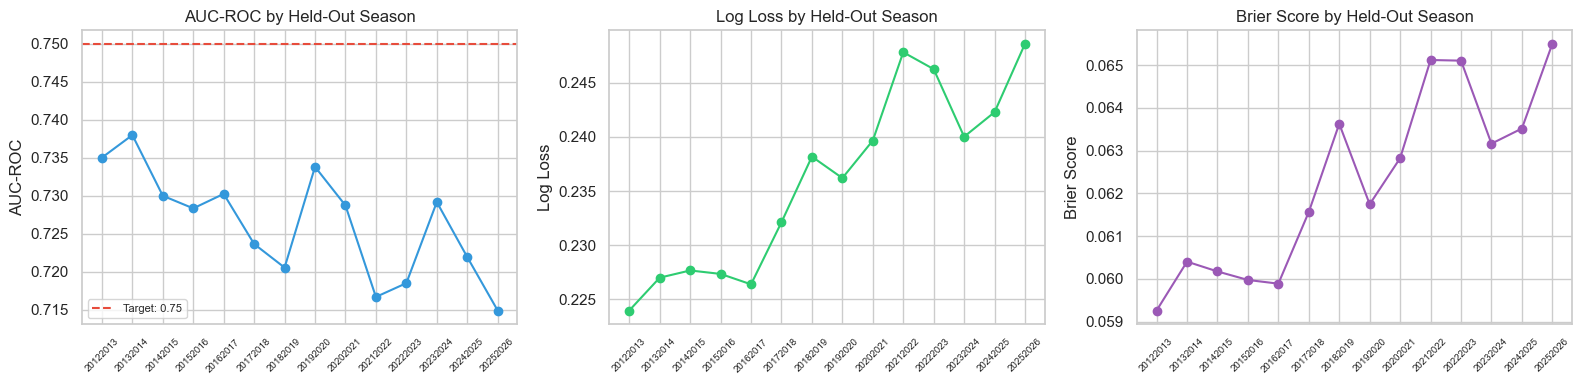


Baseline model (distance + angle + shot_type):
  Mean AUC-ROC: 0.7264 +/- 0.0069
  Mean Log Loss: 0.2360
  Mean Brier:    0.0623
  AUC target (0.75): NOT MET

  AUC trend: slope = -0.0012/season (p=0.0040)
  AUC stable (drift < 0.02/season)


In [17]:
# ── 3d. Temporal CV summary + drift detection ───────────────────────

AUC_TARGET = 0.75
AUC_DRIFT_THRESHOLD_PER_SEASON = 0.02

if cv_results:
    test_seasons_cv = [r["test_season"] for r in cv_results]
    aucs = [r["auc_roc"] for r in cv_results]
    log_losses = [r["log_loss"] for r in cv_results]
    briers = [r["brier"] for r in cv_results]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))

    axes[0].plot(test_seasons_cv, aucs, "o-", color="#3498db")
    axes[0].axhline(y=AUC_TARGET, color="#e74c3c", linestyle="--",
                    label=f"Target: {AUC_TARGET}")
    axes[0].set_ylabel("AUC-ROC")
    axes[0].set_title("AUC-ROC by Held-Out Season")
    axes[0].legend(fontsize=8)

    axes[1].plot(test_seasons_cv, log_losses, "o-", color="#2ecc71")
    axes[1].set_ylabel("Log Loss")
    axes[1].set_title("Log Loss by Held-Out Season")

    axes[2].plot(test_seasons_cv, briers, "o-", color="#9b59b6")
    axes[2].set_ylabel("Brier Score")
    axes[2].set_title("Brier Score by Held-Out Season")

    for ax in axes:
        ax.tick_params(axis="x", rotation=45, labelsize=7)

    fig.tight_layout()
    plt.show()

    # Summary stats
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    print(f"\nBaseline model (distance + angle + shot_type):")
    print(f"  Mean AUC-ROC: {mean_auc:.4f} +/- {std_auc:.4f}")
    print(f"  Mean Log Loss: {np.mean(log_losses):.4f}")
    print(f"  Mean Brier:    {np.mean(briers):.4f}")
    print(f"  AUC target ({AUC_TARGET}): {'MET' if mean_auc >= AUC_TARGET else 'NOT MET'}")

    # Drift detection: linear trend in AUC
    if len(aucs) >= 3:
        x_trend = np.arange(len(aucs))
        auc_drift_slope, auc_drift_intercept, auc_drift_r_value, auc_drift_p_value, auc_drift_std_err = sp_stats.linregress(x_trend, aucs)
        print(f"\n  AUC trend: slope = {auc_drift_slope:+.4f}/season (p={auc_drift_p_value:.4f})")
        if abs(auc_drift_slope) > AUC_DRIFT_THRESHOLD_PER_SEASON:
            print(f"  WARNING: AUC drift exceeds {AUC_DRIFT_THRESHOLD_PER_SEASON}/season threshold")
        else:
            print(f"  AUC stable (drift < {AUC_DRIFT_THRESHOLD_PER_SEASON}/season)")
else:
    print("No CV results to summarize.")

---
## Step 4: Calibration Analysis

For a rare-event model (~8% base rate), calibration matters more than discrimination.
A naive model predicting 0.08 for every shot achieves decent log loss. The model must
produce probabilities that are *accurate*, not just *ranked correctly*.

**Checks:**
- Reliability diagram (calibration curve) pooled across all folds
- Per-segment calibration: even strength, power play, short-handed
- Hosmer-Lemeshow goodness-of-fit test
- Calibration slope and intercept per held-out season

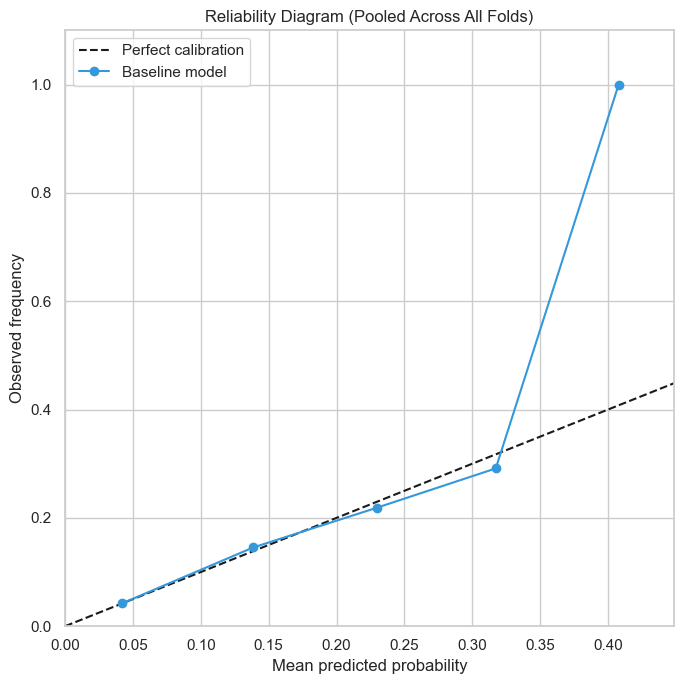

Hosmer-Lemeshow test: statistic=4270.91, dof=8, p=0.0000
  Result: FAIL (p <= 0.05, miscalibrated)



Calibration slope: 0.8737  (target: [0.95, 1.05])
Calibration intercept: -0.2756  (target: near 0)
  Slope in target range: NO


In [18]:
# ── 4a. Pooled calibration curve ─────────────────────────────────────
# HL test, calibration slope/intercept, and all thresholds come from
# src/validation.py.

if cv_results:
    # Pool all held-out predictions
    y_pool = np.concatenate([r["y_test"] for r in cv_results])
    prob_pool = np.concatenate([r["y_prob"] for r in cv_results])

    # Calibration curve
    prob_true, prob_pred = calibration_curve(y_pool, prob_pool, n_bins=CALIBRATION_N_BINS)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
    ax.plot(prob_pred, prob_true, "o-", color="#3498db", label="Baseline model")
    ax.set_xlabel("Mean predicted probability")
    ax.set_ylabel("Observed frequency")
    ax.set_title("Reliability Diagram (Pooled Across All Folds)")
    ax.legend()
    ax.set_xlim(0, max(0.3, prob_pred.max() * 1.1))
    ax.set_ylim(0, max(0.3, prob_true.max() * 1.1))
    fig.tight_layout()
    plt.show()

    hl_stat, hl_p, hl_dof = hosmer_lemeshow_test(y_pool, prob_pool)
    print(f"Hosmer-Lemeshow test: statistic={hl_stat:.2f}, dof={hl_dof}, p={hl_p:.4f}")
    print(f"  Result: {'PASS (p > 0.05)' if hl_p > HOSMER_LEMESHOW_ALPHA else 'FAIL (p <= 0.05, miscalibrated)'}")

    slope, intercept = calibration_slope_intercept(y_pool, prob_pool)
    print(f"\nCalibration slope: {slope:.4f}  (target: [{CALIBRATION_SLOPE_TARGET_LOW}, {CALIBRATION_SLOPE_TARGET_HIGH}])")
    print(f"Calibration intercept: {intercept:.4f}  (target: near 0)")
    in_range = CALIBRATION_SLOPE_TARGET_LOW <= slope <= CALIBRATION_SLOPE_TARGET_HIGH
    print(f"  Slope in target range: {'YES' if in_range else 'NO'}")
else:
    print("No CV results for calibration analysis.")


In [19]:
# ── 4b. Per-segment calibration (ES / PP / SH) ─────────────────────
# Check that the model is not systematically miscalibrated for any
# manpower segment. This is critical because PP goal rates are ~2x ES.

MAX_SUBGROUP_CALIBRATION_ERROR = 0.03

if cv_results:
    # Rebuild manpower arrays aligned to the CV folds
    mp_arr = np.array(manpower_states)

    segment_defs = {
        "Even Strength": EVEN_STRENGTH_STATES,
        "Power Play": PP_STATES,
        "Short-Handed": SH_STATES,
    }

    # Pool across folds, tracking which rows came from test sets
    test_indices_all = []
    offset = 0
    for fold_idx in range(MIN_TRAIN_SEASONS, len(unique_seasons)):
        test_season = unique_seasons[fold_idx]
        test_mask = row_seasons_arr == test_season
        test_idx = np.where(test_mask)[0]
        test_indices_all.extend(test_idx)

    test_indices_all = np.array(test_indices_all)
    mp_test = mp_arr[test_indices_all]

    print(f"{'Segment':<20} {'Shots':>8} {'Obs Rate':>9} {'Pred Rate':>10} "
          f"{'Cal Error':>10} {'HL p-val':>9} {'Status':>8}")
    print("-" * 78)

    segment_results = {}
    for seg_name, seg_states in segment_defs.items():
        seg_mask = np.array([m in seg_states for m in mp_test])

        if seg_mask.sum() == 0:
            print(f"{seg_name:<20} {'No data':>8}")
            continue

        y_seg = y_pool[seg_mask]
        p_seg = prob_pool[seg_mask]

        obs_rate = y_seg.mean()
        pred_rate = p_seg.mean()
        cal_error = abs(obs_rate - pred_rate)

        hl_s, hl_p, _ = hosmer_lemeshow_test(y_seg, p_seg)
        status = "PASS" if cal_error < MAX_SUBGROUP_CALIBRATION_ERROR else "FAIL"

        segment_results[seg_name] = {
            "n": seg_mask.sum(),
            "obs_rate": obs_rate,
            "pred_rate": pred_rate,
            "cal_error": cal_error,
            "hl_p": hl_p,
            "status": status,
        }

        print(f"{seg_name:<20} {seg_mask.sum():>8,} {obs_rate*100:>8.2f}% "
              f"{pred_rate*100:>9.2f}% {cal_error*100:>9.2f}pp "
              f"{hl_p:>9.4f} {status:>8}")

    print(f"\nMax acceptable calibration error: {MAX_SUBGROUP_CALIBRATION_ERROR*100:.1f}pp")
else:
    print("No CV results for segment calibration.")

Segment                 Shots  Obs Rate  Pred Rate  Cal Error  HL p-val   Status
------------------------------------------------------------------------------


Even Strength        1,286,388     5.95%      6.69%      0.74pp    0.0000     PASS
Power Play            264,190     9.36%      7.77%      1.59pp    0.0000     PASS


Short-Handed           47,915    17.22%      6.26%     10.96pp    0.0000     FAIL

Max acceptable calibration error: 3.0pp


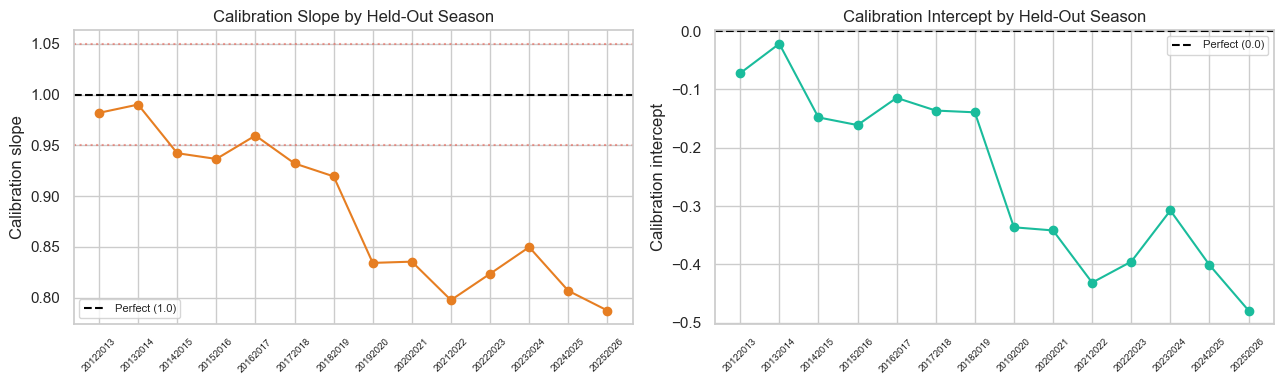

\nSeason          Slope  Intercept  Slope OK?
--------------------------------------------
20122013       0.9819    -0.0723        YES
20132014       0.9901    -0.0218        YES
20142015       0.9422    -0.1481         NO
20152016       0.9365    -0.1612         NO
20162017       0.9596    -0.1146        YES
20172018       0.9321    -0.1364         NO
20182019       0.9194    -0.1394         NO
20192020       0.8341    -0.3365         NO
20202021       0.8354    -0.3418         NO
20212022       0.7975    -0.4313         NO
20222023       0.8234    -0.3953         NO
20232024       0.8497    -0.3077         NO
20242025       0.8067    -0.4011         NO
20252026       0.7872    -0.4791         NO


In [20]:
# ── 4c. Calibration slope per held-out season ────────────────────────
# Track whether calibration degrades over time (concept drift).

if cv_results:
    cal_slopes = []
    cal_intercepts = []
    for r in cv_results:
        s, i = calibration_slope_intercept(r["y_test"], r["y_prob"])
        cal_slopes.append(s)
        cal_intercepts.append(i)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

    ax1.plot(test_seasons_cv, cal_slopes, "o-", color="#e67e22")
    ax1.axhline(y=1.0, color="black", linestyle="--", label="Perfect (1.0)")
    ax1.axhline(y=CALIBRATION_SLOPE_TARGET_LOW, color="#e74c3c", linestyle=":", alpha=0.5)
    ax1.axhline(y=CALIBRATION_SLOPE_TARGET_HIGH, color="#e74c3c", linestyle=":", alpha=0.5)
    ax1.set_ylabel("Calibration slope")
    ax1.set_title("Calibration Slope by Held-Out Season")
    ax1.legend(fontsize=8)
    ax1.tick_params(axis="x", rotation=45, labelsize=7)

    ax2.plot(test_seasons_cv, cal_intercepts, "o-", color="#1abc9c")
    ax2.axhline(y=0.0, color="black", linestyle="--", label="Perfect (0.0)")
    ax2.set_ylabel("Calibration intercept")
    ax2.set_title("Calibration Intercept by Held-Out Season")
    ax2.legend(fontsize=8)
    ax2.tick_params(axis="x", rotation=45, labelsize=7)

    fig.tight_layout()
    plt.show()

    # Per-season table
    print(f"\\n{'Season':<12} {'Slope':>8} {'Intercept':>10} {'Slope OK?':>10}")
    print("-" * 44)
    for s, sl, ic in zip(test_seasons_cv, cal_slopes, cal_intercepts):
        ok = "YES" if CALIBRATION_SLOPE_TARGET_LOW <= sl <= CALIBRATION_SLOPE_TARGET_HIGH else "NO"
        print(f"{s:<12} {sl:>8.4f} {ic:>10.4f} {ok:>10}")
else:
    print("No CV results for per-season calibration.")

---
## Step 5: Conditional Feature Importance (Ablation)

The existing notebooks ask "does this feature correlate with goals?" but never
"does adding this feature to a model that already includes distance + angle + shot type
improve predictions?" This step answers the second question.

For each candidate feature group, we compare **baseline + feature** vs. **baseline only**
using the same temporal CV harness from Step 3.

**Feature groups tested:**
1. Manpower state (one-hot)
2. Score state (one-hot)
3. Faceoff zone code (one-hot)
4. Faceoff recency: continuous log(seconds_since_faceoff + 1) vs. binned
5. Combined: all of the above

In [21]:
# ── 5a. Build augmented feature matrices ─────────────────────────────

# Manpower state (one-hot)
mp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
mp_encoded = mp_encoder.fit_transform(
    np.array([m if m else "UNKNOWN" for m in manpower_states]).reshape(-1, 1)
)

# Score state (one-hot)
ss_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
ss_encoded = ss_encoder.fit_transform(
    np.array([s if s else "UNKNOWN" for s in score_states]).reshape(-1, 1)
)

# Faceoff zone code (one-hot)
fz_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
fz_encoded = fz_encoder.fit_transform(
    np.array([z if z else "UNKNOWN" for z in fo_zones]).reshape(-1, 1)
)

# Faceoff recency — continuous: log(seconds_since_faceoff + 1)
fo_seconds = np.array([s if s is not None else -1 for s in seconds_since_fo], dtype=float)
fo_has_value = fo_seconds >= 0
fo_log_continuous = np.where(fo_has_value, np.log1p(fo_seconds), 0.0).reshape(-1, 1)
fo_missing_flag = (~fo_has_value).astype(float).reshape(-1, 1)
X_fo_continuous = np.column_stack([fo_log_continuous, fo_missing_flag])

# Faceoff recency — binned (replicating existing notebook approach)
FACEOFF_BIN_EDGES = [0, 5, 10, 20, 40, np.inf]  # seconds
FACEOFF_BIN_LABELS = ["0-5s", "6-10s", "11-20s", "21-40s", "40s+"]
fo_bins = np.full(len(fo_seconds), "UNKNOWN", dtype=object)
for i, s in enumerate(fo_seconds):
    if s < 0:
        continue
    for j in range(len(FACEOFF_BIN_EDGES) - 1):
        if FACEOFF_BIN_EDGES[j] <= s < FACEOFF_BIN_EDGES[j + 1]:
            fo_bins[i] = FACEOFF_BIN_LABELS[j]
            break

fo_bin_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X_fo_binned = fo_bin_encoder.fit_transform(fo_bins.reshape(-1, 1))

# Define feature-group augmentations
feature_groups = {
    "manpower_state": mp_encoded,
    "score_state": ss_encoded,
    "faceoff_zone": fz_encoded,
    "faceoff_recency_continuous": X_fo_continuous,
    "faceoff_recency_binned": X_fo_binned,
    "all_combined": np.column_stack([
        mp_encoded, ss_encoded, fz_encoded, X_fo_continuous
    ]),
}

for name, X_extra in feature_groups.items():
    print(f"  {name}: {X_extra.shape[1]} extra columns")

C:\Users\micha\AppData\Local\Temp\ipykernel_21684\2516680135.py:24: RuntimeWarning: divide by zero encountered in log1p
  fo_log_continuous = np.where(fo_has_value, np.log1p(fo_seconds), 0.0).reshape(-1, 1)
C:\Users\micha\AppData\Local\Temp\ipykernel_21684\2516680135.py:24: RuntimeWarning: invalid value encountered in log1p
  fo_log_continuous = np.where(fo_has_value, np.log1p(fo_seconds), 0.0).reshape(-1, 1)


  manpower_state: 16 extra columns
  score_state: 7 extra columns
  faceoff_zone: 4 extra columns
  faceoff_recency_continuous: 2 extra columns
  faceoff_recency_binned: 6 extra columns
  all_combined: 29 extra columns


In [22]:
# ── 5b. Ablation: run temporal CV for each feature group ─────────────
# run_temporal_cv comes from src/validation.py.

# Baseline results (already computed in Step 3)
baseline_metrics = {
    "mean_auc": np.mean([r["auc_roc"] for r in cv_results]),
    "mean_log_loss": np.mean([r["log_loss"] for r in cv_results]),
    "mean_brier": np.mean([r["brier"] for r in cv_results]),
}

# Run ablation for each feature group
ablation_results = {}
for group_name, X_extra in feature_groups.items():
    X_aug = np.column_stack([X_baseline, X_extra])
    fold_results = run_temporal_cv(X_aug, y, row_seasons_arr, unique_seasons)

    if fold_results:
        mean_auc = np.mean([r["auc_roc"] for r in fold_results])
        mean_ll = np.mean([r["log_loss"] for r in fold_results])
        mean_brier = np.mean([r["brier"] for r in fold_results])
        ablation_results[group_name] = {
            "mean_auc": mean_auc,
            "mean_log_loss": mean_ll,
            "mean_brier": mean_brier,
            "delta_auc": mean_auc - baseline_metrics["mean_auc"],
            "delta_log_loss": mean_ll - baseline_metrics["mean_log_loss"],
            "delta_brier": mean_brier - baseline_metrics["mean_brier"],
            "folds": fold_results,
        }

# Print ablation table
print(f"\n{'Feature Group':<30} {'AUC':>7} {'dAUC':>7} {'LogLoss':>8} {'dLL':>7} "
      f"{'Brier':>7} {'dBrier':>7}")
print("-" * 78)
print(f"{'BASELINE (dist+angle+type)':<30} {baseline_metrics['mean_auc']:>7.4f} "
      f"{'---':>7} {baseline_metrics['mean_log_loss']:>8.4f} {'---':>7} "
      f"{baseline_metrics['mean_brier']:>7.4f} {'---':>7}")

for name, res in ablation_results.items():
    auc_arrow = "+" if res["delta_auc"] > 0 else ""
    print(f"{name:<30} {res['mean_auc']:>7.4f} {auc_arrow}{res['delta_auc']:>6.4f} "
          f"{res['mean_log_loss']:>8.4f} {res['delta_log_loss']:>+6.4f} "
          f"{res['mean_brier']:>7.4f} {res['delta_brier']:>+6.4f}")

print("\nPositive dAUC = improvement. Negative dLogLoss/dBrier = improvement.")



Feature Group                      AUC    dAUC  LogLoss     dLL   Brier  dBrier
------------------------------------------------------------------------------
BASELINE (dist+angle+type)      0.7264     ---   0.2360     ---  0.0623     ---
manpower_state                  0.7546 +0.0282   0.2256 -0.0104  0.0606 -0.0016
score_state                     0.7270 +0.0006   0.2356 -0.0004  0.0623 -0.0000
faceoff_zone                    0.7279 +0.0014   0.2354 -0.0006  0.0621 -0.0001
faceoff_recency_continuous      0.7269 +0.0005   0.2357 -0.0003  0.0622 -0.0000
faceoff_recency_binned          0.7271 +0.0007   0.2357 -0.0003  0.0622 -0.0001
all_combined                    0.7547 +0.0283   0.2256 -0.0104  0.0606 -0.0016

Positive dAUC = improvement. Negative dLogLoss/dBrier = improvement.


In [23]:
# ── 5c. Continuous vs. binned faceoff recency comparison ─────────────
# The existing notebooks use arbitrary round-number bins (0-5s, 6-10s, etc.).
# The exponential decay analysis suggests continuous is more natural.

if "faceoff_recency_continuous" in ablation_results and "faceoff_recency_binned" in ablation_results:
    cont = ablation_results["faceoff_recency_continuous"]
    binned = ablation_results["faceoff_recency_binned"]

    print("Faceoff Recency: Continuous vs. Binned")
    print("=" * 50)
    print(f"  {'Representation':<25} {'AUC':>7} {'LogLoss':>8} {'Brier':>7}")
    print(f"  {'-' * 47}")
    print(f"  {'Continuous (log1p):':<25} {cont['mean_auc']:>7.4f} "
          f"{cont['mean_log_loss']:>8.4f} {cont['mean_brier']:>7.4f}")
    print(f"  {'Binned (5s/10s/20s/40s):':<25} {binned['mean_auc']:>7.4f} "
          f"{binned['mean_log_loss']:>8.4f} {binned['mean_brier']:>7.4f}")

    auc_diff = cont["mean_auc"] - binned["mean_auc"]
    winner = "Continuous" if auc_diff > 0 else "Binned"
    print(f"\n  AUC difference: {auc_diff:+.4f} ({winner} wins)")
    print(f"  Recommendation: Use {'continuous' if auc_diff >= 0 else 'binned'} representation")
    if abs(auc_diff) < 0.001:
        print("  (Difference is negligible — either is fine)")
else:
    print("Faceoff recency ablation results not available.")

Faceoff Recency: Continuous vs. Binned
  Representation                AUC  LogLoss   Brier
  -----------------------------------------------
  Continuous (log1p):        0.7269   0.2357  0.0622
  Binned (5s/10s/20s/40s):   0.7271   0.2357  0.0622

  AUC difference: -0.0001 (Binned wins)
  Recommendation: Use binned representation
  (Difference is negligible — either is fine)


---
## Step 5b: Venue Bias - Prior-Season Validation

The existing `venue_bias_analysis.ipynb` computes per-season z-scores and checks
seasonal stability. Same-season venue diagnostics cannot be used inside temporal CV
because they are computed from outcomes in the held-out season. This step validates
venue-bias features using only diagnostics from seasons before each shot:

1. Does a prior-season mean venue z-score improve held-out model performance?
2. Does the most recent prior-season z-score outperform the prior-season mean?
3. Are there scorer turnover effects (z-score sign flips between seasons)?


In [24]:
cur.execute("""
    SELECT venue_name, season, shot_count_z_score
    FROM venue_bias_diagnostics
    WHERE shot_count_z_score IS NOT NULL
    ORDER BY venue_name, season
""")
vd_rows = cur.fetchall()

from collections import defaultdict
venue_z_by_season = defaultdict(list)
for r in vd_rows:
    venue_z_by_season[r[0]].append((str(r[1]), r[2]))

MIN_SEASONS_FOR_STABILITY = 3
sign_flip_venues = []

for venue, season_z_list in venue_z_by_season.items():
    if len(season_z_list) < MIN_SEASONS_FOR_STABILITY:
        continue
    flips = 0
    for i in range(1, len(season_z_list)):
        prev_z = season_z_list[i - 1][1]
        curr_z = season_z_list[i][1]
        if prev_z * curr_z < 0 and (abs(prev_z) > 1.0 or abs(curr_z) > 1.0):
            flips += 1
    if flips > 0:
        sign_flip_venues.append((venue, flips, len(season_z_list)))

if sign_flip_venues:
    print(f"Venues with z-score sign flips (potential scorer turnover):")
    print(f"{'Venue':<35} {'Flips':>6} {'Seasons':>8}")
    print("-" * 52)
    for venue, flips, n_seasons in sorted(sign_flip_venues, key=lambda x: -x[1]):
        print(f"{venue:<35} {flips:>6} {n_seasons:>8}")
    print(f"\n{len(sign_flip_venues)} venues show sign flips.")
    print("These venues need per-season correction (pooled would cancel out).")
else:
    print("No significant z-score sign flips detected.")

Venues with z-score sign flips (potential scorer turnover):
Venue                                Flips  Seasons
----------------------------------------------------
Barclays Center                          2        6
Bridgestone Arena                        2       17
Nationwide Arena                         2       19
Amalie Arena                             1       11
CONSOL Energy Center                     1        7
Centre Bell                              1       19
General Motors Place                     1        4
HP Pavilion at San Jose                  1        5
Jobing.com Arena                         1        6
MTS Centre                               1        7
Prudential Center                        1       19
St. Pete Times Forum                     1        5
Verizon Center                           1       11
Wachovia Center                          1        3

14 venues show sign flips.
These venues need per-season correction (pooled would cancel out).


In [25]:
shot_venues = [row["venue_name"] for row in all_rows]
shot_seasons_for_venue = [str(row["season"]) for row in all_rows]


def build_prior_venue_z_feature(mode):
    """Return a fold-safe venue-z feature using seasons before each shot only."""
    values = []
    for venue, season in zip(shot_venues, shot_seasons_for_venue):
        if not venue:
            values.append(0.0)
            continue

        prior_values = [
            (prior_season, z_score)
            for prior_season, z_score in venue_z_by_season.get(venue, [])
            if prior_season < season
        ]
        if not prior_values:
            values.append(0.0)
        elif mode == "latest":
            values.append(sorted(prior_values, key=lambda item: item[0])[-1][1])
        elif mode == "mean":
            values.append(float(np.mean([z_score for _, z_score in prior_values])))
        else:
            raise ValueError(f"Unsupported venue-z mode: {mode}")

    return np.array(values, dtype=float).reshape(-1, 1)


venue_feature_groups = {
    "venue_z_prior_mean": build_prior_venue_z_feature("mean"),
    "venue_z_prior_latest": build_prior_venue_z_feature("latest"),
}

venue_ablation = {}
for label, X_venue in venue_feature_groups.items():
    nonzero_count = int(np.count_nonzero(X_venue))
    if nonzero_count == 0:
        print(f"{label}: no prior-season diagnostics available; skipping.")
        continue

    X_aug = np.column_stack([X_baseline, X_venue])
    fold_results = run_temporal_cv(X_aug, y, row_seasons_arr, unique_seasons)
    if fold_results:
        mean_auc = np.mean([r["auc_roc"] for r in fold_results])
        mean_ll = np.mean([r["log_loss"] for r in fold_results])
        venue_ablation[label] = {
            "mean_auc": mean_auc,
            "mean_log_loss": mean_ll,
            "delta_auc": mean_auc - baseline_metrics["mean_auc"],
            "delta_log_loss": mean_ll - baseline_metrics["mean_log_loss"],
            "nonzero_rows": nonzero_count,
        }

print("Venue Bias Feature Ablation (prior-season, leakage-safe):")
print(f"  {'Method':<25} {'Rows':>10} {'AUC':>7} {'dAUC':>7} {'LogLoss':>8} {'dLL':>7}")
print(f"  {'-' * 66}")
print(f"  {'Baseline':<25} {len(y):>10,} {baseline_metrics['mean_auc']:>7.4f} {'---':>7} "
      f"{baseline_metrics['mean_log_loss']:>8.4f} {'---':>7}")
for label, res in venue_ablation.items():
    print(f"  {label:<25} {res['nonzero_rows']:>10,} {res['mean_auc']:>7.4f} "
          f"{res['delta_auc']:>+6.4f} {res['mean_log_loss']:>8.4f} "
          f"{res['delta_log_loss']:>+6.4f}")

if len(venue_ablation) >= 2:
    best_label, best_res = max(venue_ablation.items(), key=lambda item: item[1]["mean_auc"])
    print(f"\n  Best prior-season venue feature by held-out AUC: {best_label} "
          f"(dAUC = {best_res['delta_auc']:+.4f}).")
elif not venue_ablation:
    print("\n  No venue ablation was run because prior-season diagnostics were unavailable.")

print("\nSame-season and pooled-all-season venue z-scores remain exploratory only; they are not used in temporal CV.")


Venue Bias Feature Ablation (prior-season, leakage-safe):
  Method                          Rows     AUC    dAUC  LogLoss     dLL
  ------------------------------------------------------------------
  Baseline                   1,965,107  0.7264     ---   0.2360     ---
  venue_z_prior_mean         1,821,039  0.7264 +0.0000   0.2360 -0.0000
  venue_z_prior_latest       1,821,039  0.7264 -0.0000   0.2360 -0.0000

  Best prior-season venue feature by held-out AUC: venue_z_prior_mean (dAUC = +0.0000).

Same-season and pooled-all-season venue z-scores remain exploratory only; they are not used in temporal CV.


---
## Step 6: Leakage Audit Table

Systematic per-feature documentation of leakage risk. For every feature in the
`shot_events` and `game_context` tables, we assess:

- **Available at shot time?** — Could this feature be known *before* the shot occurs?
- **Encodes post-shot information?** — Does this feature contain the outcome or future events?
- **Proxies for confounder?** — Could this feature be a proxy for an unmeasured variable?

In [26]:
# ── 6. Leakage audit ─────────────────────────────────────────────────

leakage_audit = [
    # (feature, table, available_at_shot_time, post_shot_info, confounder_proxy, notes)
    ("distance_to_goal", "shot_events", "YES", "NO", "LOW",
     "Computed from shot coordinates. Unambiguously pre-shot."),
    ("angle_to_goal", "shot_events", "YES", "NO", "LOW",
     "Computed from shot coordinates. Unambiguously pre-shot."),
    ("shot_type", "shot_events", "YES", "NO", "LOW",
     "Recorded by scorekeeper at event time."),
    ("x_coord / y_coord", "shot_events", "YES", "NO", "MEDIUM",
     "Normalized coordinates. Venue scorekeeper bias may distort values."),
    ("score_state", "shot_events", "YES", "NO", "MEDIUM",
     "Pre-event score via _track_score(). No goal leakage. But score state "
     "correlates with team quality (confound with shot quality)."),
    ("manpower_state", "shot_events", "YES", "NO", "LOW",
     "Derived from situation code at event time. Well-defined."),
    ("time_remaining_seconds", "shot_events", "YES", "NO", "LOW",
     "Game clock at event time. No leakage."),
    ("period", "shot_events", "YES", "NO", "LOW",
     "Period number at event time. No leakage."),
    ("faceoff_zone_code", "shot_events", "AMBIGUOUS", "NO", "MEDIUM",
     "CONCERN: Records the zone from the faceoff winner's perspective, not "
     "necessarily the shooting team's. If zone code implicitly reveals which "
     "team controlled play post-faceoff, it leaks possession information. "
     "Needs validation that zone is resolved to shooting team's perspective."),
    ("seconds_since_faceoff", "shot_events", "YES", "NO", "MEDIUM",
     "CONCERN: No maximum cap. If a whistle occurs but isn't recorded as a "
     "faceoff, this can be arbitrarily large and refer to a stale context. "
     "Consider capping at a staleness threshold (e.g., 120s)."),
    ("is_goal", "shot_events", "TARGET", "N/A", "N/A",
     "This is the prediction target. Must never be used as a feature."),
    ("home_rest_days", "game_context", "YES", "NO", "HIGH",
     "CONCERN: Rest days correlate with schedule structure, which correlates "
     "with team quality. Without controlling for team strength, rest may "
     "proxy for team quality rather than genuine fatigue."),
    ("away_rest_days", "game_context", "YES", "NO", "HIGH",
     "Same concern as home_rest_days."),
    ("rest_advantage", "game_context", "YES", "NO", "HIGH",
     "Derived from rest days. Same confounder concern."),
    ("travel_distance_km", "game_context", "YES", "NO", "MEDIUM",
     "Haversine distance. Correlates with conference/division structure."),
    ("timezone_delta", "game_context", "YES", "NO", "MEDIUM",
     "East-west travel proxy. Correlates with conference membership."),
    ("venue z-score (prior-season only)", "venue_bias_diagnostics", "YES", "NO", "LOW",
     "Fold-safe ablation uses diagnostics from seasons before each shot only. "
     "Same-season or pooled-all-season diagnostics remain exploratory and "
     "must not feed temporal CV."),
]

# Print as table
print(f"{'Feature':<28} {'Table':<18} {'Pre-shot':>9} {'Post-shot':>10} "
      f"{'Confound':>9}")
print("=" * 78)
for feat, table, pre, post, confound, notes in leakage_audit:
    print(f"{feat:<28} {table:<18} {pre:>9} {post:>10} {confound:>9}")

print("\n\nDETAILED NOTES:")
print("-" * 78)
for feat, table, pre, post, confound, notes in leakage_audit:
    if "CONCERN" in notes or confound == "HIGH" or pre == "AMBIGUOUS":
        print(f"\n  {feat} ({table}):")
        print(f"    {notes}")

Feature                      Table               Pre-shot  Post-shot  Confound
distance_to_goal             shot_events              YES         NO       LOW
angle_to_goal                shot_events              YES         NO       LOW
shot_type                    shot_events              YES         NO       LOW
x_coord / y_coord            shot_events              YES         NO    MEDIUM
score_state                  shot_events              YES         NO    MEDIUM
manpower_state               shot_events              YES         NO       LOW
time_remaining_seconds       shot_events              YES         NO       LOW
period                       shot_events              YES         NO       LOW
faceoff_zone_code            shot_events        AMBIGUOUS         NO    MEDIUM
seconds_since_faceoff        shot_events              YES         NO    MEDIUM
is_goal                      shot_events           TARGET        N/A       N/A
home_rest_days               game_context           

---
## Step 7: Validation Scorecard

Aggregate all checks into a single pass/fail scorecard. This is the gate
that must be cleared before proceeding to production model training.

All thresholds are defined as named constants throughout this notebook.

In [27]:
# ── 7. Validation Scorecard ──────────────────────────────────────────

scorecard = []

# 1. Data quality
quality_pass = all(v == 0 for v in quality.values())
scorecard.append(("Data quality (contract checks)", quality_pass,
                  "All zero" if quality_pass else "Violations found"))

# 2. Discrimination (AUC)
if cv_results:
    mean_auc_score = np.mean([r["auc_roc"] for r in cv_results])
    auc_pass = mean_auc_score >= AUC_TARGET
    scorecard.append(("Discrimination (AUC >= 0.75)", auc_pass,
                      f"Mean AUC = {mean_auc_score:.4f}"))
else:
    scorecard.append(("Discrimination (AUC >= 0.75)", False, "No CV results"))

# 3. Calibration slope
if cv_results:
    pooled_slope, _ = calibration_slope_intercept(y_pool, prob_pool)
    slope_pass = CALIBRATION_SLOPE_TARGET_LOW <= pooled_slope <= CALIBRATION_SLOPE_TARGET_HIGH
    scorecard.append(("Calibration slope [0.95, 1.05]", slope_pass,
                      f"Slope = {pooled_slope:.4f}"))
else:
    scorecard.append(("Calibration slope [0.95, 1.05]", False, "No CV results"))

# 4. Hosmer-Lemeshow
if cv_results:
    hl_pass = hl_p > HOSMER_LEMESHOW_ALPHA
    scorecard.append(("Hosmer-Lemeshow (p > 0.05)", hl_pass,
                      f"p = {hl_p:.4f}"))
else:
    scorecard.append(("Hosmer-Lemeshow (p > 0.05)", False, "No CV results"))

# 5. Temporal stability (AUC drift)
if cv_results and len(aucs) >= 3:
    drift_pass = abs(auc_drift_slope) <= AUC_DRIFT_THRESHOLD_PER_SEASON
    scorecard.append(("Temporal stability (drift < 0.02/season)", drift_pass,
                      f"Slope = {auc_drift_slope:+.4f}/season"))
else:
    scorecard.append(("Temporal stability (drift < 0.02/season)", False,
                      "Insufficient folds"))

# 6. Subgroup calibration
if segment_results:
    max_cal_error = max(r["cal_error"] for r in segment_results.values())
    subgroup_pass = max_cal_error < MAX_SUBGROUP_CALIBRATION_ERROR
    scorecard.append(("Subgroup calibration (error < 3pp)", subgroup_pass,
                      f"Max error = {max_cal_error*100:.2f}pp"))
else:
    scorecard.append(("Subgroup calibration (error < 3pp)", False,
                      "No segment results"))

# 7. Feature-level: at least one feature group improves baseline
if ablation_results:
    any_improves = any(r["delta_auc"] > 0 for r in ablation_results.values())
    best_group = max(ablation_results.items(), key=lambda x: x[1]["delta_auc"])
    scorecard.append(("Feature ablation (>= 1 group improves)", any_improves,
                      f"Best: {best_group[0]} (dAUC = {best_group[1]['delta_auc']:+.4f})"))
else:
    scorecard.append(("Feature ablation (>= 1 group improves)", False,
                      "No ablation results"))

# 8. Leakage audit
n_high_risk = sum(1 for _, _, pre, _, conf, _ in leakage_audit
                  if conf == "HIGH" or pre == "AMBIGUOUS")
leakage_pass = n_high_risk == 0
scorecard.append(("Leakage audit (no HIGH/AMBIGUOUS)", leakage_pass,
                  f"{n_high_risk} features flagged" if not leakage_pass
                  else "All clear"))

# Print scorecard
print("=" * 70)
print("VALIDATION SCORECARD")
print("=" * 70)
n_pass = 0
n_fail = 0
for criterion, passed, detail in scorecard:
    status = "PASS" if passed else "FAIL"
    if passed:
        n_pass += 1
    else:
        n_fail += 1
    print(f"  [{status}] {criterion}")
    print(f"         {detail}")

print(f"\n{'=' * 70}")
print(f"RESULT: {n_pass}/{len(scorecard)} checks passed, {n_fail} failed")
if n_fail == 0:
    print("MODEL TRAINING MAY PROCEED.")
else:
    print("BLOCKED — resolve failures before training.")
    print("\nFailed checks require investigation:")
    for criterion, passed, detail in scorecard:
        if not passed:
            print(f"  - {criterion}: {detail}")

VALIDATION SCORECARD
  [PASS] Data quality (contract checks)
         All zero
  [FAIL] Discrimination (AUC >= 0.75)
         Mean AUC = 0.7264
  [FAIL] Calibration slope [0.95, 1.05]
         Slope = 0.8737
  [FAIL] Hosmer-Lemeshow (p > 0.05)
         p = 0.0000
  [PASS] Temporal stability (drift < 0.02/season)
         Slope = -0.0012/season
  [FAIL] Subgroup calibration (error < 3pp)
         Max error = 10.96pp
  [PASS] Feature ablation (>= 1 group improves)
         Best: all_combined (dAUC = +0.0283)
  [FAIL] Leakage audit (no HIGH/AMBIGUOUS)
         4 features flagged

RESULT: 3/8 checks passed, 5 failed
BLOCKED — resolve failures before training.

Failed checks require investigation:
  - Discrimination (AUC >= 0.75): Mean AUC = 0.7264
  - Calibration slope [0.95, 1.05]: Slope = 0.8737
  - Hosmer-Lemeshow (p > 0.05): p = 0.0000
  - Subgroup calibration (error < 3pp): Max error = 10.96pp
  - Leakage audit (no HIGH/AMBIGUOUS): 4 features flagged


In [28]:
conn.close()
print("Done.")

Done.
